# Benchmarks

Data Source: https://github.com/blof/LINERLIB

In [1]:
from pprint import pprint

import pandas as pd

import cma
from test_benchmarks_utils import \
	read_vessel_class_data, \
	read_port_data, \
	read_demand

In [2]:
pacific = [
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore',
	'Brunei', 'Timor-Leste',
	'China', 'Japan', 'South Korea', 'North Korea',
	'Canada', 'Mexico',
	'Fiji', 'Australia'
]
_, cma_portpool = cma.read_port_data()

In [3]:
vessel_pool = read_vessel_class_data()
portpool = read_port_data(vessel_pool, cma_portpool)

In [4]:
portpool.get_number_of_ports()

45

In Total  45  ports are plotted


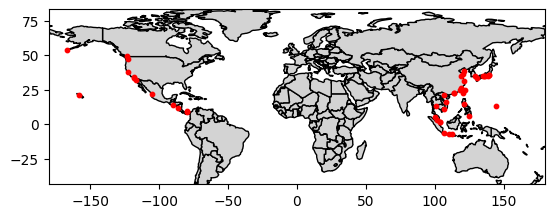

In [5]:
_ = portpool.plot(pacific)

In [6]:
week_demands, unit_revenue = read_demand(portpool)
dist_mat = cma.read_sailing_distance_data(portpool)

In [7]:
# create a new pool of ports with richer information
portgraph = cma.PortGraph(portpool, dist_mat, week_demands, unit_revenue)
num_ports = portgraph.get_number_of_ports()
print(f'In total {num_ports} have freight demand')
portgraph

In total 45 have freight demand


[SVAQJ, JPSMZ, CNLYG, VNHPH, PAMIT, USSEA, USDUT, MYPEN, THLCH, IDSRG, CNFOC, VNSGN, KRPUS, USHNL, CAVAN, JPNGO, MYPKG, CNDLC, IDSUB, TWKEL, GUGUM, USLAX, TWKHH, CNXMN, JPTYO, PABLB, JPUKB, USOAK, CNTAO, IDJKT, PHGES, NICIO, MYTPP, JPOSA, PHMNL, CNYTN, HKHKG, JPYOK, JPHKT, USLGB, MXLZC, MXESE, VNDAD, CNSHA, SGSIN]

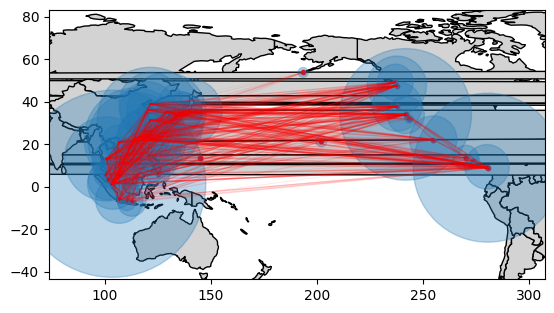

In [8]:
# plot the demands between ports
_, ax, _ = portgraph.plot(pacific, center_pacific=True)

In [9]:
# load current lines
initial_lines = cma.randomly_create_lines(portpool, 15)
print(f'Successfully load {len(initial_lines)} lines')

45
Successfully load 15 lines


In [10]:
# create a graph network
servicegraph = cma.ServiceGraph(initial_lines)
servicegraph

line_1 -- [PHMNL, CNTAO]
line_2 -- [PAMIT, MXLZC]
line_3 -- [NICIO, PHMNL]
line_4 -- [CNYTN, PABLB]
line_5 -- [JPUKB, JPYOK]
line_6 -- [CNYTN, CNLYG]
line_7 -- [HKHKG, CAVAN]
line_8 -- [CNLYG, SVAQJ]
line_9 -- [HKHKG, CNYTN]
line_10 -- [PHGES, GUGUM]
line_11 -- [IDSUB, PHMNL]
line_12 -- [TWKHH, MYPKG]
line_13 -- [KRPUS, USSEA]
line_14 -- [JPOSA, JPNGO]
line_15 -- [GUGUM, PAMIT]

In [11]:
# servicegraph.plot( \
# 	lines_info=[
# 		('line_1', 'firebrick'), ('line_2', 'firebrick'),
# 		('line_3', 'firebrick'), ('line_4', 'firebrick'),
# 		('line_5', 'firebrick'), ('line_6', 'firebrick'),
# 		('line_7', 'firebrick'), ('line_8', 'firebrick'),
# 		('line_9', 'firebrick'), ('line_10', 'firebrick'),
# 		('line_11', 'firebrick'), ('line_12', 'firebrick'),
# 		('line_13', 'firebrick'), ('line_14', 'firebrick'),
# 		('line_15', 'firebrick')
# 	], selected_countries=pacific,
# 	portgraph=portgraph,
# )

In [12]:
# create a week prediction model
week_predictor = cma.create_week_predictor()
week_predictor.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:               OLS              Adj. R-squared:     0.890   
Dependent Variable:  weeks            AIC:                92.3843 
Date:                2025-07-23 15:47 BIC:                103.7352
No. Observations:    49               Log-Likelihood:     -40.192 
Df Model:            5                F-statistic:        78.32   
Df Residuals:        43               Prob (F-statistic): 1.77e-20
R-squared:           0.901            Scale:              0.34412 
------------------------------------------------------------------
                     Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
------------------------------------------------------------------
const               -0.5318   0.4189 -1.2695 0.2111 -1.3767 0.3130
sailing_distance     0.0005   0.0000 13.8420 0.0000  0.0004 0.0005
stops_number         0.0549   0.0379  1.4485 0.1547 -0.0215 0.1313
ave_productivity     0.0009   0.0022  0.4213 0.6757 -0.0035 0.0053
ave_demand_inflows   0.0002   0.0001  1.7211 0.0924 -0.0000 0.0005
ave_demand_outflows  0.0001   0.0002  0.5632 0.5763 -0.0003 0.0006
------------------------------------------------------------------
Omnibus:               8.717        Durbin-Watson:           1.521
Prob(Omnibus):         0.013        Jarque-Bera (JB):        7.882
Skew:                  0.909        Prob(JB):                0.019
Kurtosis:              3.743        Condition No.:           33496
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [13]:
# solve the optimal demand fulfillment
servicegraph.solve_approximated(portgraph, vessel_pool, week_predictor, min_cost=False)
servicegraph.total_profit()

>>> hello


0.0